In [1]:
%reload_ext autoreload
%autoreload 2

import os
import pickle
import numpy as np
import json

from fpp.utils.validation import pp_finite_sample_band
from fpp.utils.posterior import multi_corner

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../src/fpp/utils/matplotlibrc")

# TMP

In [ ]:
from fpp.models.np_model import NPModel
m = NPModel()
z = np.load(os.environ['MYSTORE'] + f"/fermi/fermi-prob-prog/outputs/production/simulations/fullprior42.npy")

No data provided. Using Fermi data.


In [ ]:
for i in range(100):
    data = z[i]
    print(f'{i}, {np.max(data[~m.mask_roi]):5.0f}, {np.max(data[~m.nm]):5.0f}, {np.max(data):5.0f}')

# Coverage

In [2]:
run_name = 'calibration/hmc-fullprior-zeroAlm-king'
z = pickle.load(open(os.environ['MYSTORE'] + f'/fermi/fermi-prob-prog/outputs/production/fits/{run_name}/p_nominal_actual_dict.p', 'rb'))
keys = list(z.keys())
keys.sort()
print(' '.join(keys))

C S_bub S_gce S_ics S_iso S_pib S_psc Sps_dsk Sps_gce f_bulge_poiss f_bulge_ps gamma_poiss gamma_ps lambdas_dsk lambdas_gce n1_dsk n1_gce n2_dsk n2_gce n3_dsk n3_gce sb1_dsk sb1_gce zs


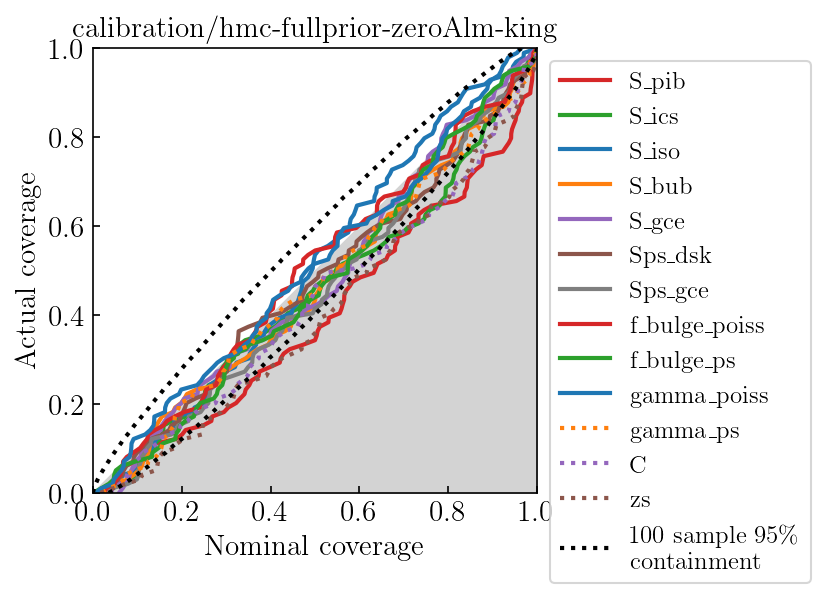

In [3]:
if 'pois' in run_name:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'f_bulge_poiss', 'gamma_poiss',
    ]
else:
    labels = [
        'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce',
        'Sps_dsk', 'Sps_gce',
        'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
    ]

probs = [z[k] for k in labels]
ls_s = ['-'] * 10 + [':'] * 10

fig, ax = plt.subplots()

ax.fill_between([0,1], [0,1], color='lightgray')
if labels is None:
    labels = [None for _ in probs]
for prob, label, ls in zip(probs, labels, ls_s):
    ax.plot(prob[0], prob[1], label=label, ls=ls)

n_run = len(probs[0][0])
lower, upper = pp_finite_sample_band(n_run)
ax.plot(upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(lower, np.linspace(0, 1, n_run), 'k:')

ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage', title=run_name)

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
plt.tight_layout()

# Corner

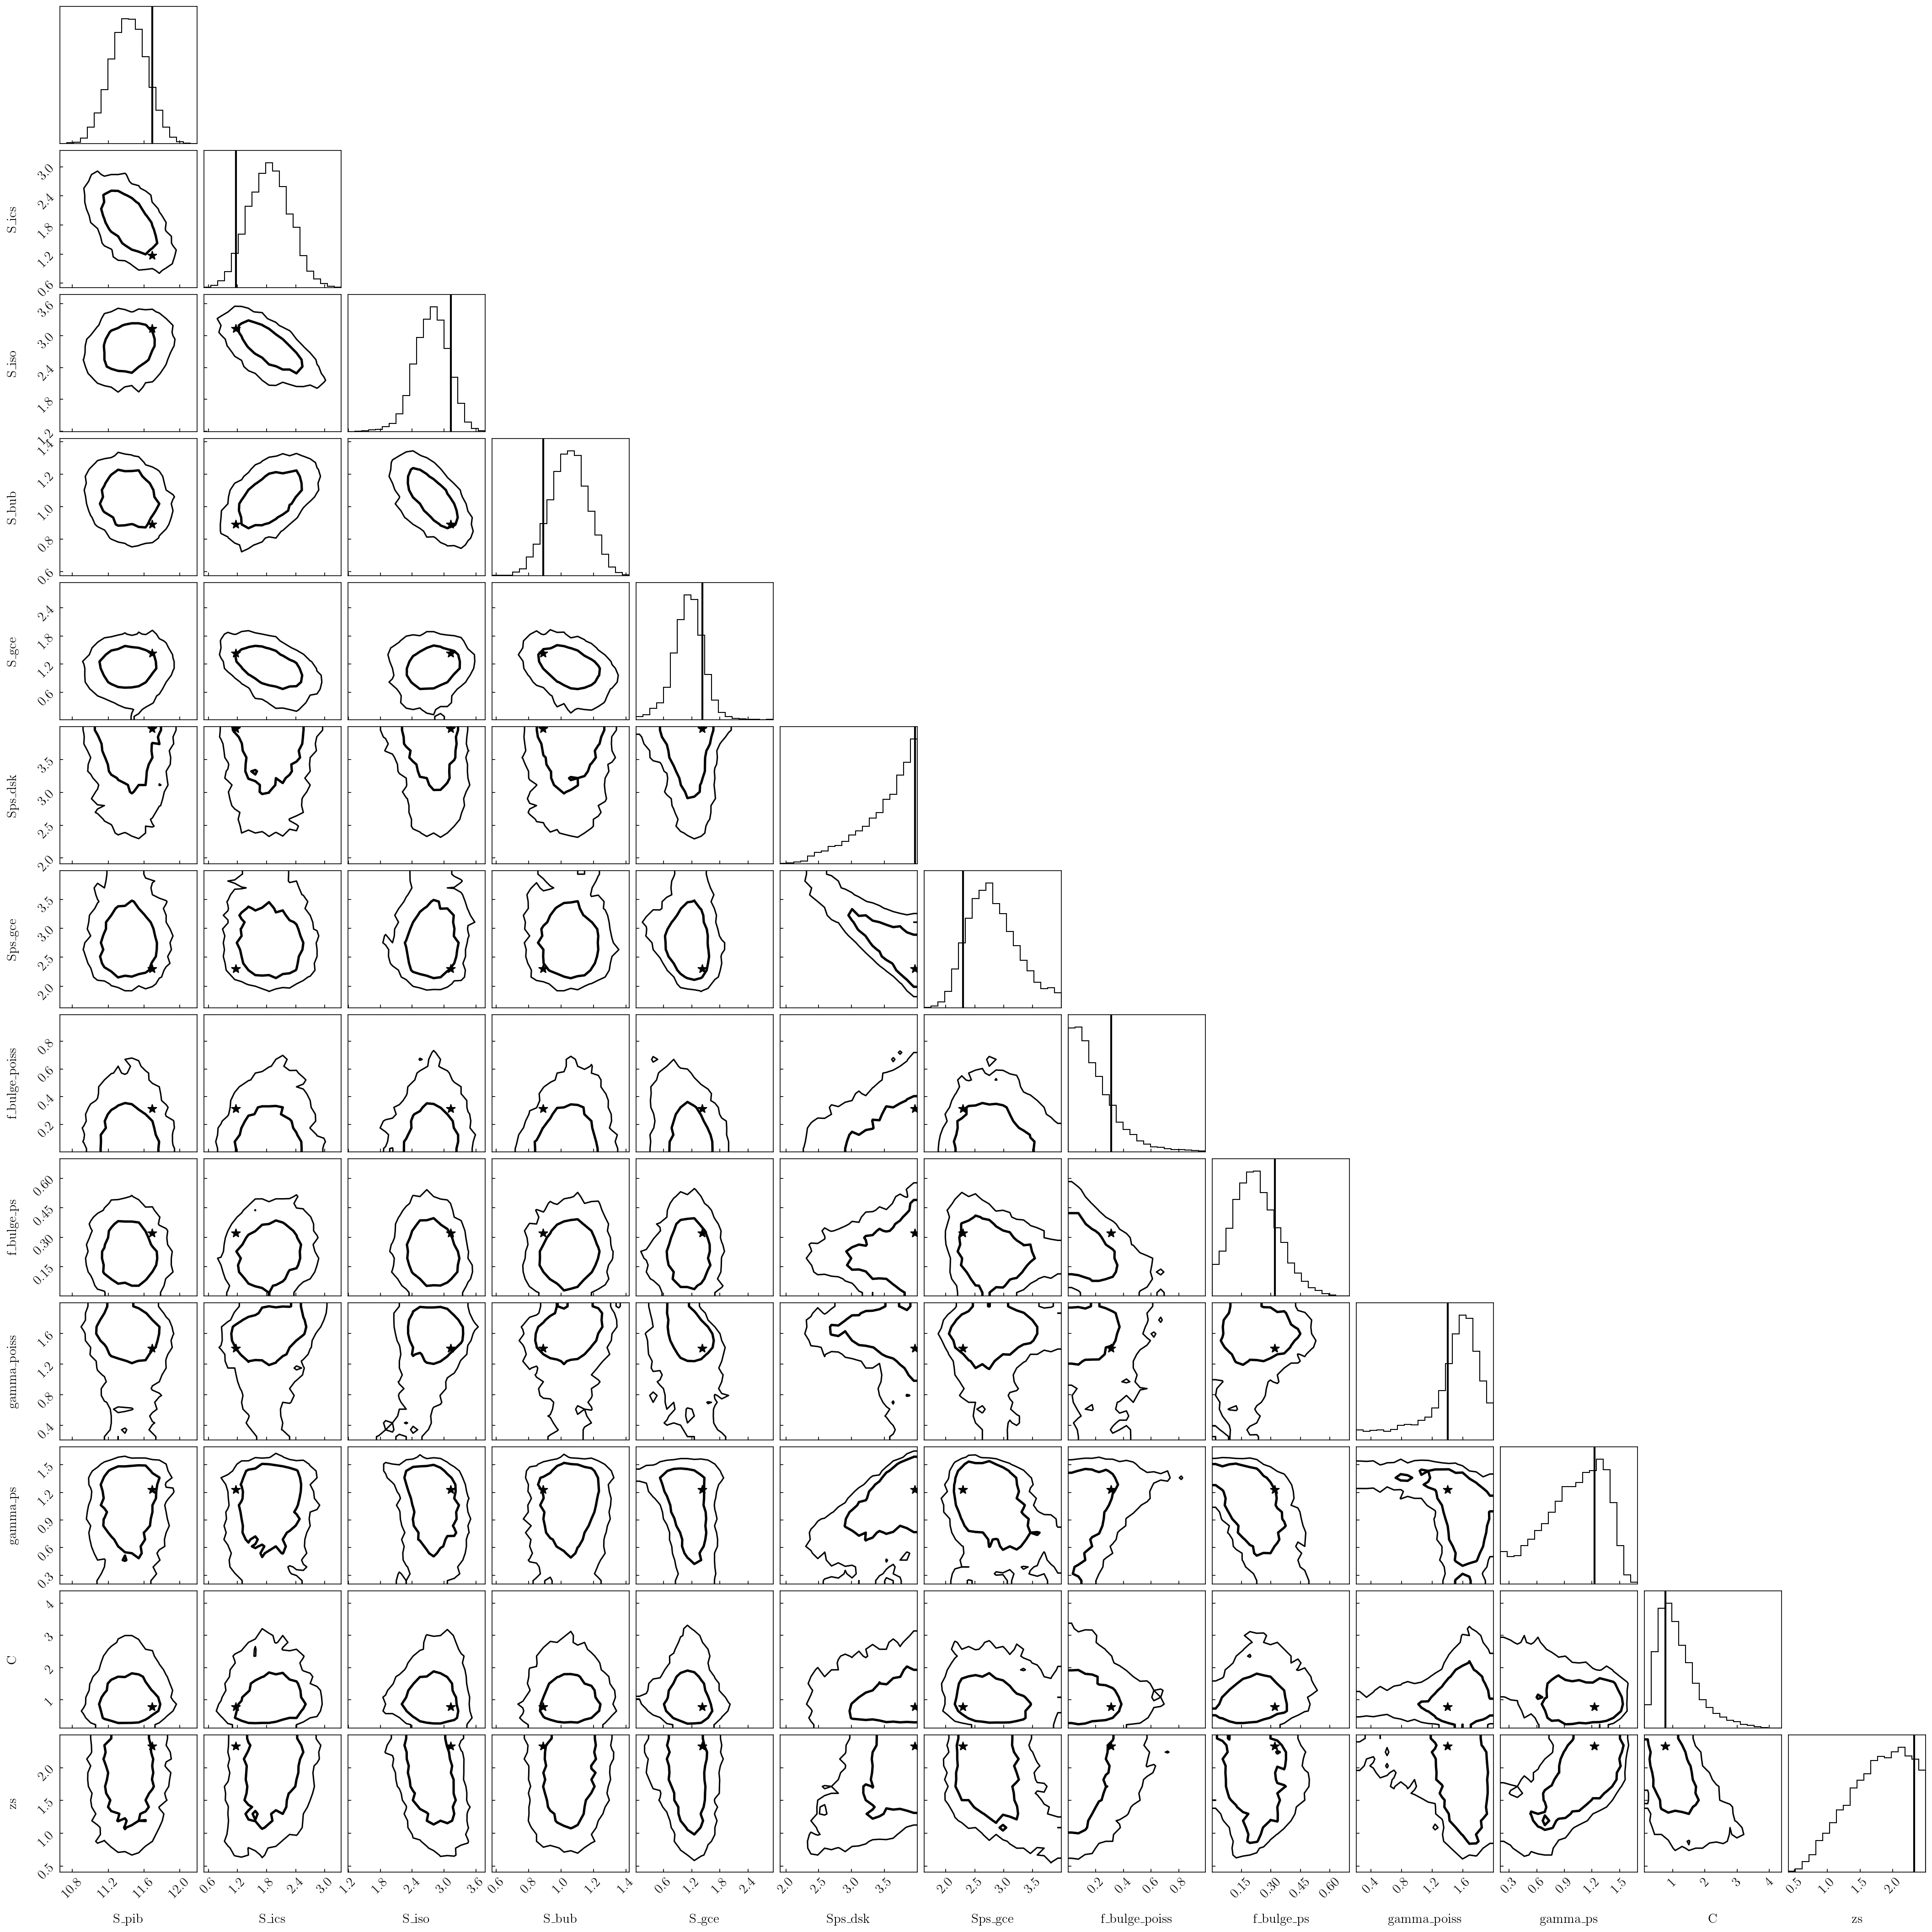

In [4]:
point_est = True
full_prior_i = 1
truth_dict = json.load(open("../outputs/truths/truths_fullprior42-zeroAlm.json", 'r'))

if full_prior_i:
    truth_dict = truth_dict[full_prior_i]
labels = [
    'S_pib', 'S_ics', 'S_iso', 'S_bub', 'S_gce', 'Sps_dsk', 'Sps_gce',
    'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'
]
config_dict = {
    'hmc' : (os.environ['MYSTORE'] + f'/fermi/fermi-prob-prog/outputs/production/fits/calibration/hmc-fullprior-zeroAlm-king/1.p', 'k'),
    # 'pt' : ('/n/home07/yitians/fermi/fermi-prob-prog/outputs/production/fits/calibration/pthmc-old-delta-2/4.p', 'r'),
}

s_in = {}
labels_dict = {}
colors_dict = {}
for key, (path, color) in config_dict.items():
    s = pickle.load(open(path, 'rb'))
    s_in[key] = {k: s[k] for k in labels}
    labels_dict[key] = key
    colors_dict[key] = color

t_in = {k: truth_dict[k] for k in labels} if point_est else None

multi_corner(s_in, labels, point_est=t_in, colors_dict=colors_dict, labels_dict=labels_dict)